In [1]:

# imports
import os
import sys
import types
import json
import base64

# figure size/format
fig_width = 7
fig_height = 5
fig_format = 'retina'
fig_dpi = 96
interactivity = ''
is_shiny = False
is_dashboard = False
plotly_connected = True

# matplotlib defaults / format
try:
  import matplotlib.pyplot as plt
  plt.rcParams['figure.figsize'] = (fig_width, fig_height)
  plt.rcParams['figure.dpi'] = fig_dpi
  plt.rcParams['savefig.dpi'] = "figure"

  # IPython 7.14 deprecated set_matplotlib_formats from IPython
  try:
    from matplotlib_inline.backend_inline import set_matplotlib_formats
  except ImportError:
    # Fall back to deprecated location for older IPython versions
    from IPython.display import set_matplotlib_formats
    
  set_matplotlib_formats(fig_format)
except Exception:
  pass

# plotly use connected mode
try:
  import plotly.io as pio
  if plotly_connected:
    pio.renderers.default = "notebook_connected"
  else:
    pio.renderers.default = "notebook"
  for template in pio.templates.keys():
    pio.templates[template].layout.margin = dict(t=30,r=0,b=0,l=0)
except Exception:
  pass

# disable itables paging for dashboards
if is_dashboard:
  try:
    from itables import options
    options.dom = 'fiBrtlp'
    options.maxBytes = 1024 * 1024
    options.language = dict(info = "Showing _TOTAL_ entries")
    options.classes = "display nowrap compact"
    options.paging = False
    options.searching = True
    options.ordering = True
    options.info = True
    options.lengthChange = False
    options.autoWidth = False
    options.responsive = True
    options.keys = True
    options.buttons = []
  except Exception:
    pass
  
  try:
    import altair as alt
    # By default, dashboards will have container sized
    # vega visualizations which allows them to flow reasonably
    theme_sentinel = '_quarto-dashboard-internal'
    def make_theme(name):
        nonTheme = alt.themes._plugins[name]    
        def patch_theme(*args, **kwargs):
            existingTheme = nonTheme()
            if 'height' not in existingTheme:
              existingTheme['height'] = 'container'
            if 'width' not in existingTheme:
              existingTheme['width'] = 'container'

            if 'config' not in existingTheme:
              existingTheme['config'] = dict()
            
            # Configure the default font sizes
            title_font_size = 15
            header_font_size = 13
            axis_font_size = 12
            legend_font_size = 12
            mark_font_size = 12
            tooltip = False

            config = existingTheme['config']

            # The Axis
            if 'axis' not in config:
              config['axis'] = dict()
            axis = config['axis']
            if 'labelFontSize' not in axis:
              axis['labelFontSize'] = axis_font_size
            if 'titleFontSize' not in axis:
              axis['titleFontSize'] = axis_font_size  

            # The legend
            if 'legend' not in config:
              config['legend'] = dict()
            legend = config['legend']
            if 'labelFontSize' not in legend:
              legend['labelFontSize'] = legend_font_size
            if 'titleFontSize' not in legend:
              legend['titleFontSize'] = legend_font_size  

            # The header
            if 'header' not in config:
              config['header'] = dict()
            header = config['header']
            if 'labelFontSize' not in header:
              header['labelFontSize'] = header_font_size
            if 'titleFontSize' not in header:
              header['titleFontSize'] = header_font_size    

            # Title
            if 'title' not in config:
              config['title'] = dict()
            title = config['title']
            if 'fontSize' not in title:
              title['fontSize'] = title_font_size

            # Marks
            if 'mark' not in config:
              config['mark'] = dict()
            mark = config['mark']
            if 'fontSize' not in mark:
              mark['fontSize'] = mark_font_size

            # Mark tooltips
            if tooltip and 'tooltip' not in mark:
              mark['tooltip'] = dict(content="encoding")

            return existingTheme
            
        return patch_theme

    # We can only do this once per session
    if theme_sentinel not in alt.themes.names():
      for name in alt.themes.names():
        alt.themes.register(name, make_theme(name))
      
      # register a sentinel theme so we only do this once
      alt.themes.register(theme_sentinel, make_theme('default'))
      alt.themes.enable('default')

  except Exception:
    pass

# enable pandas latex repr when targeting pdfs
try:
  import pandas as pd
  if fig_format == 'pdf':
    pd.set_option('display.latex.repr', True)
except Exception:
  pass

# interactivity
if interactivity:
  from IPython.core.interactiveshell import InteractiveShell
  InteractiveShell.ast_node_interactivity = interactivity

# NOTE: the kernel_deps code is repeated in the cleanup.py file
# (we can't easily share this code b/c of the way it is run).
# If you edit this code also edit the same code in cleanup.py!

# output kernel dependencies
kernel_deps = dict()
for module in list(sys.modules.values()):
  # Some modules play games with sys.modules (e.g. email/__init__.py
  # in the standard library), and occasionally this can cause strange
  # failures in getattr.  Just ignore anything that's not an ordinary
  # module.
  if not isinstance(module, types.ModuleType):
    continue
  path = getattr(module, "__file__", None)
  if not path:
    continue
  if path.endswith(".pyc") or path.endswith(".pyo"):
    path = path[:-1]
  if not os.path.exists(path):
    continue
  kernel_deps[path] = os.stat(path).st_mtime
print(json.dumps(kernel_deps))

# set run_path if requested
run_path = 'L2hvbWUvY2hhbmNlL3F1YXJ0by1sYWIvdGhlb3J5L09TRg=='
if run_path:
  # hex-decode the path
  run_path = base64.b64decode(run_path.encode("utf-8")).decode("utf-8")
  os.chdir(run_path)

# reset state
%reset

# shiny
# Checking for shiny by using False directly because we're after the %reset. We don't want
# to set a variable that stays in global scope.
if False:
  try:
    import htmltools as _htmltools
    import ast as _ast

    _htmltools.html_dependency_render_mode = "json"

    # This decorator will be added to all function definitions
    def _display_if_has_repr_html(x):
      try:
        # IPython 7.14 preferred import
        from IPython.display import display, HTML
      except:
        from IPython.core.display import display, HTML

      if hasattr(x, '_repr_html_'):
        display(HTML(x._repr_html_()))
      return x

    # ideally we would undo the call to ast_transformers.append
    # at the end of this block whenver an error occurs, we do 
    # this for now as it will only be a problem if the user 
    # switches from shiny to not-shiny mode (and even then likely
    # won't matter)
    import builtins
    builtins._display_if_has_repr_html = _display_if_has_repr_html

    class _FunctionDefReprHtml(_ast.NodeTransformer):
      def visit_FunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

      def visit_AsyncFunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

    ip = get_ipython()
    ip.ast_transformers.append(_FunctionDefReprHtml())

  except:
    pass

def ojs_define(**kwargs):
  import json
  try:
    # IPython 7.14 preferred import
    from IPython.display import display, HTML
  except:
    from IPython.core.display import display, HTML

  # do some minor magic for convenience when handling pandas
  # dataframes
  def convert(v):
    try:
      import pandas as pd
    except ModuleNotFoundError: # don't do the magic when pandas is not available
      return v
    if type(v) == pd.Series:
      v = pd.DataFrame(v)
    if type(v) == pd.DataFrame:
      j = json.loads(v.T.to_json(orient='split'))
      return dict((k,v) for (k,v) in zip(j["index"], j["data"]))
    else:
      return v

  v = dict(contents=list(dict(name=key, value=convert(value)) for (key, value) in kwargs.items()))
  display(HTML('<script type="ojs-define">' + json.dumps(v) + '</script>'), metadata=dict(ojs_define = True))
globals()["ojs_define"] = ojs_define
globals()["__spec__"] = None

{"/home/chance/.local/share/uv/python/cpython-3.11.15-linux-x86_64-gnu/lib/python3.11/importlib/_bootstrap.py": 1781600678.0429904, "/home/chance/.local/share/uv/python/cpython-3.11.15-linux-x86_64-gnu/lib/python3.11/importlib/_bootstrap_external.py": 1781600678.0469904, "/home/chance/.local/share/uv/python/cpython-3.11.15-linux-x86_64-gnu/lib/python3.11/zipimport.py": 1781600678.926988, "/home/chance/.local/share/uv/python/cpython-3.11.15-linux-x86_64-gnu/lib/python3.11/codecs.py": 1781600677.3309925, "/home/chance/.local/share/uv/python/cpython-3.11.15-linux-x86_64-gnu/lib/python3.11/encodings/aliases.py": 1781600677.3909922, "/home/chance/.local/share/uv/python/cpython-3.11.15-linux-x86_64-gnu/lib/python3.11/encodings/__init__.py": 1781600677.3909922, "/home/chance/.local/share/uv/python/cpython-3.11.15-linux-x86_64-gnu/lib/python3.11/encodings/utf_8.py": 1781600677.414992, "/home/chance/.local/share/uv/python/cpython-3.11.15-linux-x86_64-gnu/lib/python3.11/abc.py": 1781600677.29899

n = 1, D = 2
  Empirical mean:     -0.345989
  Theory -1/(D²-1):  -0.333333
  |Difference|:       0.012655



n = 2, D = 4
  Empirical mean:     -0.069012
  Theory -1/(D²-1):  -0.066667
  |Difference|:       0.002346



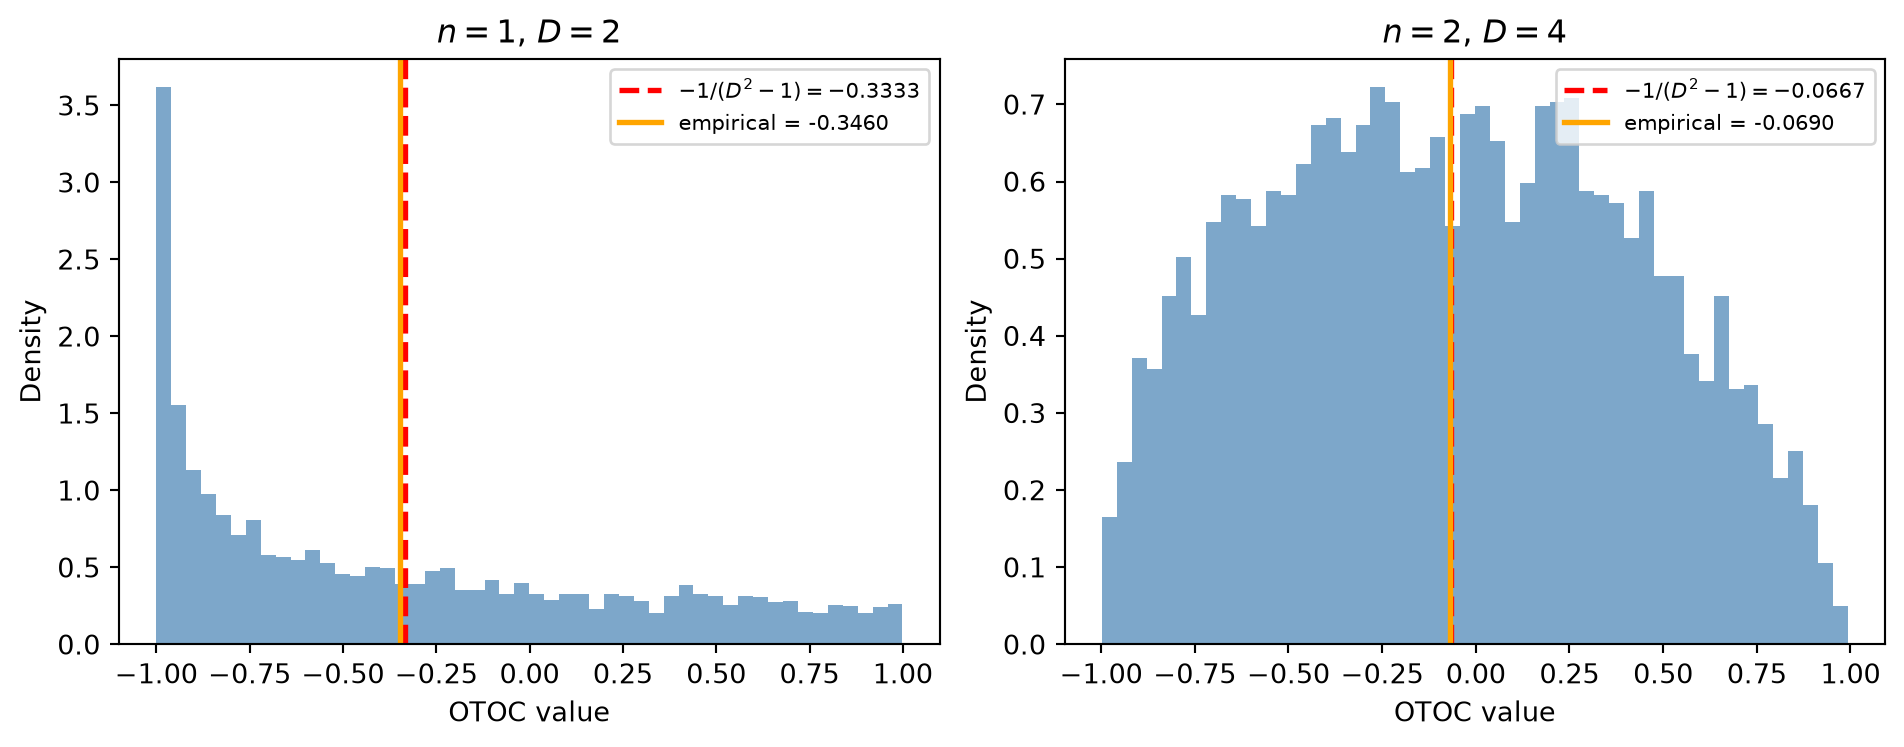

In [2]:
import numpy as np
from qiskit.quantum_info import random_unitary
import matplotlib.pyplot as plt

np.random.seed(42)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for idx, n_qubits in enumerate([1, 2]):
    D = 2**n_qubits
    n_samples = 5000

    # |0^n>
    psi = np.zeros(D, dtype=complex)
    psi[0] = 1.0

    # B: traceless Pauli (X on first qubit, I on rest)
    X = np.array([[0, 1], [1, 0]], dtype=complex)
    I2 = np.eye(2, dtype=complex)
    B = X if n_qubits == 1 else np.kron(X, np.eye(D // 2, dtype=complex))

    # M: Pauli-Z measurement (Z on all qubits), M|0^n> = |0^n>, tr(M) = 0
    Z = np.array([[1, 0], [0, -1]], dtype=complex)
    M = Z
    for _ in range(n_qubits - 1):
        M = np.kron(M, Z)

    otoc_values = []
    for _ in range(n_samples):
        U = random_unitary(D).data
        A_tilde = U.conj().T @ B @ U  # U†BU
        x = psi.conj() @ A_tilde @ M @ A_tilde @ psi
        otoc_values.append(x.real)

    theory_mean = -1 / (D**2 - 1)
    emp_mean = np.mean(otoc_values)

    print(f"n = {n_qubits}, D = {D}")
    print(f"  Empirical mean:     {emp_mean:.6f}")
    print(f"  Theory -1/(D²-1):  {theory_mean:.6f}")
    print(f"  |Difference|:       {abs(emp_mean - theory_mean):.6f}")
    print()

    axes[idx].hist(otoc_values, bins=50, density=True, alpha=0.7, color="steelblue")
    axes[idx].axvline(theory_mean, color="red", linestyle="--", linewidth=2,
                      label=f"$-1/(D^2-1) = {theory_mean:.4f}$")
    axes[idx].axvline(emp_mean, color="orange", linestyle="-", linewidth=2,
                      label=f"empirical = {emp_mean:.4f}")
    axes[idx].set_xlabel("OTOC value")
    axes[idx].set_ylabel("Density")
    axes[idx].set_title(f"$n = {n_qubits}$, $D = {D}$")
    axes[idx].legend(fontsize=8)

plt.tight_layout()
plt.show()

/home/chance/quarto-lab/.venv/lib/python3.11/site-packages/matplotlib/cbook.py:1810: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/chance/quarto-lab/.venv/lib/python3.11/site-packages/matplotlib/cbook.py:1407: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asanyarray(x, float)


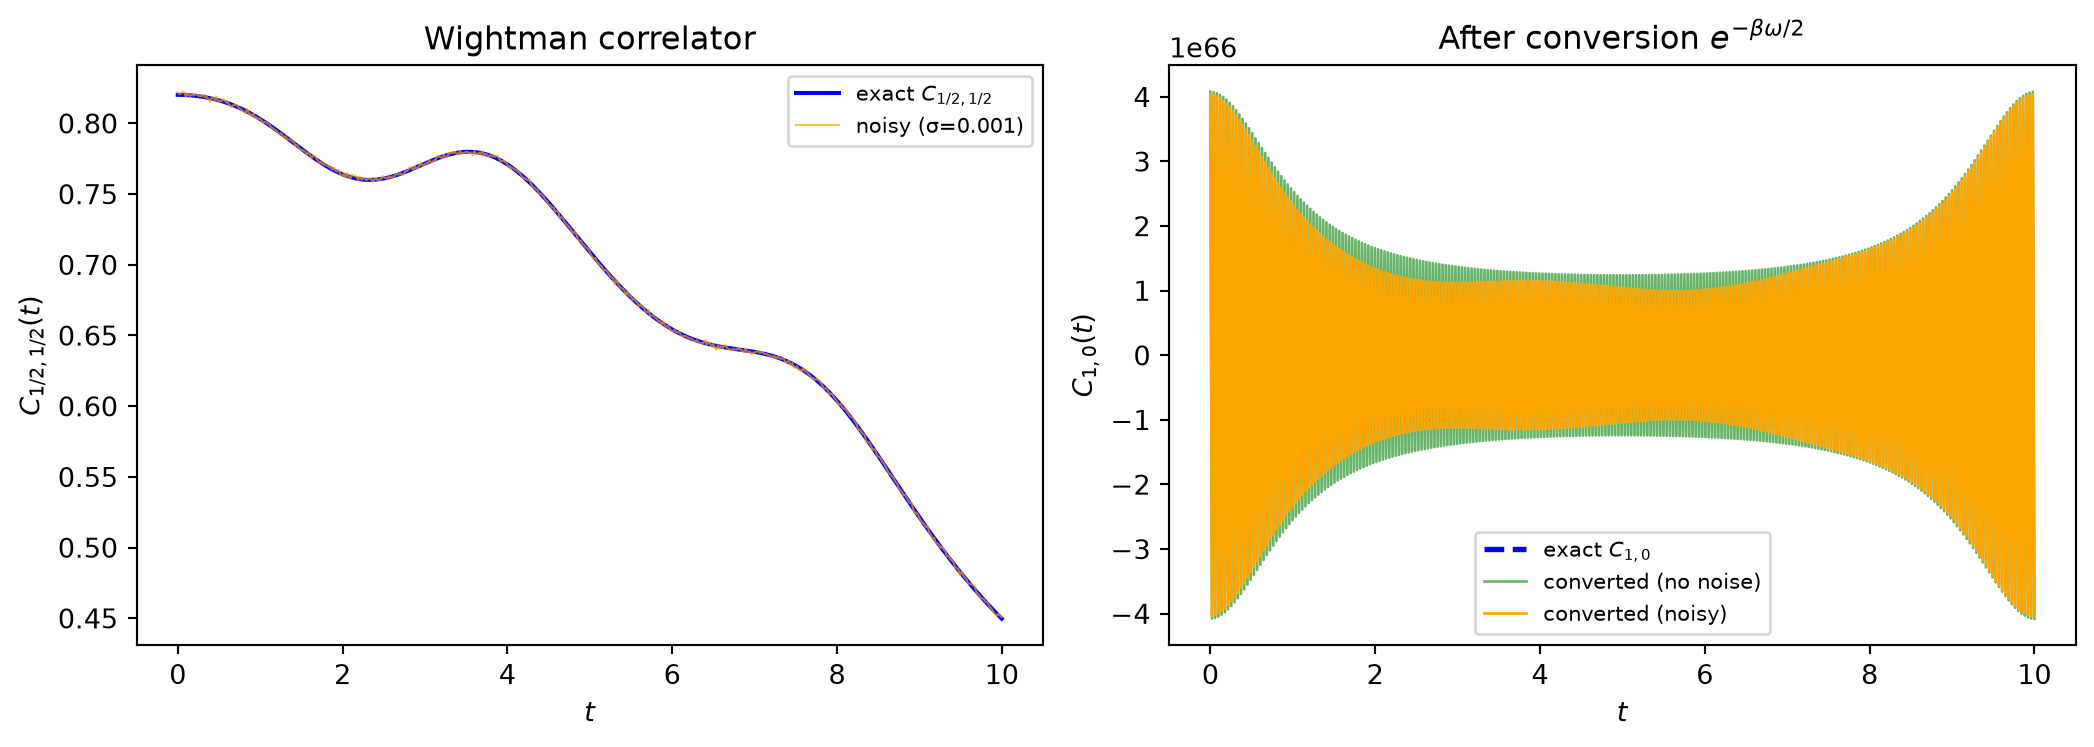

In [3]:
#| label: fig-noise-amplification
#| fig-cap: 'Ill-posedness of regularization conversion. Left: the noisy Wightman correlator $C_{1/2,1/2}(t)$ is visually indistinguishable from the exact one. Right: after frequency-domain conversion via $e^{\beta\omega/2}$, the result (orange) deviates wildly from the exact $C_{1,0}(t)$ (blue dashed).'
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm

# --- 4-site TFIM Hamiltonian ---
n = 4
D = 2**n
sx = np.array([[0,1],[1,0]], dtype=complex)
sz = np.array([[1,0],[0,-1]], dtype=complex)
Id = np.eye(2, dtype=complex)

def kron_chain(ops):
    out = ops[0]
    for o in ops[1:]:
        out = np.kron(out, o)
    return out

J, h = 1.0, 0.5
H = np.zeros((D, D), dtype=complex)
for i in range(n - 1):
    ops = [Id]*n; ops[i] = sz; ops[i+1] = sz
    H -= J * kron_chain(ops)
for i in range(n):
    ops = [Id]*n; ops[i] = sx
    H -= h * kron_chain(ops)

# Operators: O1 = sigma^z_0, O2 = sigma^z_1
ops1 = [Id]*n; ops1[0] = sz; O1 = kron_chain(ops1)
ops2 = [Id]*n; ops2[1] = sz; O2 = kron_chain(ops2)

beta = 2.0
rho = expm(-beta * H)
Z = np.trace(rho)

# --- Compute exact correlators ---
ts = np.linspace(0, 10, 512)
dt = ts[1] - ts[0]

def correlator(alpha1, alpha2, ts):
    rho1 = expm(-alpha1 * beta * H)
    rho2 = expm(-alpha2 * beta * H)
    vals = []
    for t in ts:
        U = expm(1j * H * t)
        O1t = U @ O1 @ U.conj().T
        vals.append(np.trace(rho1 @ O1t @ rho2 @ O2).real / Z)
    return np.array(vals)

C_half = correlator(0.5, 0.5, ts)   # Wightman
C_10   = correlator(1.0, 0.0, ts)   # standard

# --- Add noise to Wightman and convert ---
np.random.seed(0)
noise_level = 1e-3
C_half_noisy = C_half + noise_level * np.random.randn(len(ts))

# FFT -> multiply by exp(beta*omega/2) -> IFFT
freqs = np.fft.fftfreq(len(ts), d=dt) * 2 * np.pi
C_half_hat = np.fft.fft(C_half_noisy)
# Convert from (1/2,1/2) to (1,0): multiply by exp((0 - 1/2)*beta*omega) = exp(-beta*omega/2)
# i.e. C_{1,0}(w) = exp(-beta*w/2) * C_{1/2,1/2}(w)
# Actually from the formula: alpha_2=1/2 -> alpha'_2=0, factor = exp((alpha_2 - alpha'_2)*beta*w) = exp(beta*w/2)
# But we want C_{alpha'} = exp((alpha'_2 - alpha_2)*beta*w) * C_{alpha}
# = exp((0 - 0.5)*beta*w) * C_{1/2,1/2} = exp(-beta*w/2) * C_{1/2,1/2}
conversion = np.exp(-0.5 * beta * freqs)
C_10_converted = np.fft.ifft(C_half_hat * conversion).real

# exact conversion (no noise)
C_half_hat_exact = np.fft.fft(C_half)
C_10_exact_conv = np.fft.ifft(C_half_hat_exact * conversion).real

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(ts, C_half, 'b-', lw=1.5, label='exact $C_{1/2,1/2}$')
axes[0].plot(ts, C_half_noisy, 'orange', lw=0.8, alpha=0.7, label=f'noisy (σ={noise_level})')
axes[0].set_xlabel('$t$'); axes[0].set_ylabel('$C_{1/2,1/2}(t)$')
axes[0].set_title('Wightman correlator'); axes[0].legend(fontsize=8)

axes[1].plot(ts, C_10, 'b--', lw=2, label='exact $C_{1,0}$')
axes[1].plot(ts, C_10_exact_conv, 'g-', lw=1, alpha=0.6, label='converted (no noise)')
axes[1].plot(ts, C_10_converted, 'orange', lw=1, label='converted (noisy)')
axes[1].set_xlabel('$t$'); axes[1].set_ylabel('$C_{1,0}(t)$')
axes[1].set_title('After conversion $e^{-\\beta\\omega/2}$'); axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()